 Anup Gurung (ACE080BCT013)

Task 1: Logistic Regression Using a Single Feature

Problem Statement

Develop a Logistic Regression model using only the **Cholesterol** feature to predict whether a patient has heart disease.

Input Feature:Cholesterol

Target Variable: HeartDisease

 1. Introduction

Objective

The objective of this assignment is to understand and implement the complete Machine Learning pipeline using Logistic Regression for a binary classification problem. The task focuses on predicting the presence of heart disease using patient medical data. In this task, only the **Cholesterol** feature is used as the input variable to train the Logistic Regression model and evaluate its ability to predict the target variable, **HeartDisease**.

 2. Background

 Artificial Intelligence (AI)

Artificial Intelligence (AI) is a field of computer science that aims to create systems capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem-solving, decision-making, and pattern recognition.

Machine Learning (ML)

Machine Learning (ML) is a subset of Artificial Intelligence that enables computers to learn from data and make predictions or decisions without being explicitly programmed. ML algorithms identify patterns in data and use these patterns to improve their performance over time.

Deep Learning (DL)

Deep Learning (DL) is a specialized branch of Machine Learning that employs artificial neural networks with multiple layers to learn complex relationships within large datasets. It is widely used in applications such as image recognition, speech processing, and natural language understanding.

Data Science

Data Science is an interdisciplinary field that combines statistics, programming, mathematics, and domain knowledge to analyze data and extract meaningful insights. It plays a crucial role in solving real-world problems through data-driven decision-making.



1️⃣ Data Retrieval and Collection
Description:
The Heart Disease dataset is loaded using Pandas. The dataset contains medical information related to cardiovascular health.

In [1]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


2️⃣ Data Cleaning

In [2]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

median_cholesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print("\nTarget Variable unique values:", df['Heart Disease'].unique())
print("\nData Types:\n", df.dtypes)

Missing values per column:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Target Variable unique values: <StringArray>
['Presence', 'Absence']
Length: 2, dtype: str

Data Types:
 Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                   

3️⃣ Feature Design

In [3]:
# Select only Cholesterol for Task 1
X_single = df[['Cholesterol']] 
y = df['Heart Disease']

We are isolating Cholesterolas our single predictor matrix (X) and HeartDisease as our target vector (y). Medically, high levels of LDL cholesterol can lead to plaque buildup in arteries, increasing the risk of coronary artery disease, making it a highly relevant predictor.

4️⃣ Algorithm Selection

We choose Logistic Regression because it is fundamentally designed for binary classification problems. Instead of fitting a straight line to the data (like Linear Regression, which could output predictions outside the 0 and 1 range), Logistic Regression maps predictions to probabilities between 0 and 1 using the Sigmoid function: The Sigmoid function, defined as
Formula
σ(z)=1/(1+e^-z)​ , maps predictions to probabilities.

5️⃣ Loss Function Selection

We use Binary Cross-Entropy (also known as Log Loss). The formula is:$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$This loss function works by heavily penalizing the model when it is highly confident but wrong. If the true label is 1, the second half of the equation cancels out, and we take the log of the prediction. If the model predicted 0.01 (very wrong), taking the log results in a massive penalty/error score.

Step 6: Model Learning

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split dataset (80% training, 20% testing)
X_train_s, X_test_s, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

# Initialize and train the model
model_single = LogisticRegression()
model_single.fit(X_train_s, y_train)

print(f"Learned Coefficient (Weight): {model_single.coef_[0][0]}")
print(f"Learned Intercept (Bias): {model_single.intercept_[0]}")

Learned Coefficient (Weight): 0.0035149143902224764
Learned Intercept (Bias): -1.046984415317109


Model parameters (coefficients and intercepts) are learned using an optimization algorithm (typically Gradient Descent or solvers like 'lbfgs'). The algorithm calculates the error using our loss function, then calculates the gradient (derivative) to understand which direction to adjust the parameters to minimize that error over multiple iterations.

7️⃣ Model Evaluation

Task 1 Classification Report:
               precision    recall  f1-score   support

     Absence       0.64      0.85      0.73        33
    Presence       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



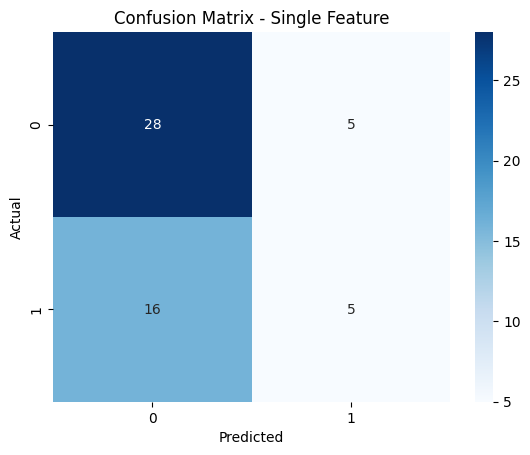

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_s = model_single.predict(X_test_s)

print("Task 1 Classification Report:\n", classification_report(y_test, y_pred_s))

# Confusion Matrix
cm_single = confusion_matrix(y_test, y_pred_s)
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Single Feature')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Accuracy measures overall correctness, precision measures prediction reliability, recall measures the ability to detect heart disease cases, and F1-score balances precision and recall. The confusion matrix shows correct and incorrect classifications.

Task 2: Logistic Regression with Multiple Features
1️⃣ Data Retrieval and Collection

In [7]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


2️⃣ Data Cleaning

In [8]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

median_cholesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

print("\nTarget Variable unique values:", df['Heart Disease'].unique())
print("\nData Types:\n", df.dtypes)

Missing values per column:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Target Variable unique values: <StringArray>
['Presence', 'Absence']
Length: 2, dtype: str

Data Types:
 Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                   

3️⃣ Feature Design

In [9]:
from sklearn.preprocessing import StandardScaler

# Separate all features from target
X_multi = df.drop('Heart Disease', axis=1)

# Encode categorical variables using One-Hot Encoding
X_multi_encoded = pd.get_dummies(X_multi, drop_first=True)

# Split first, THEN scale to avoid data leakage
X_train_m, X_test_m, y_train, y_test = train_test_split(X_multi_encoded, y, test_size=0.2, random_state=42)

# Apply Feature Scaling
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

4️⃣ Algorithm Selection

 We choose Logistic Regression because it is fundamentally designed for binary classification problems. Instead of fitting a straight line to the data (like Linear Regression, which could output predictions outside the 0 and 1 range), Logistic Regression maps predictions to probabilities between 0 and 1 using the Sigmoid function:
The Sigmoid function, defined as $S(z) = \frac{1}{1 + e^{-z}}$, maps predictions to probabilities.

5️⃣ Loss Function 

We use Binary Cross-Entropy (also known as Log Loss). The formula is:$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$This loss function works by heavily penalizing the model when it is highly confident but wrong. If the true label is 1, the second half of the equation cancels out, and we take the log of the prediction. If the model predicted 0.01 (very wrong), taking the log results in a massive penalty/error score.

6️⃣ Model Learning

In [10]:
# Train the multi-feature model
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train_m_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

7️⃣ Model Evaluation

Task 2 Classification Report:
               precision    recall  f1-score   support

     Absence       0.91      0.94      0.93        33
    Presence       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



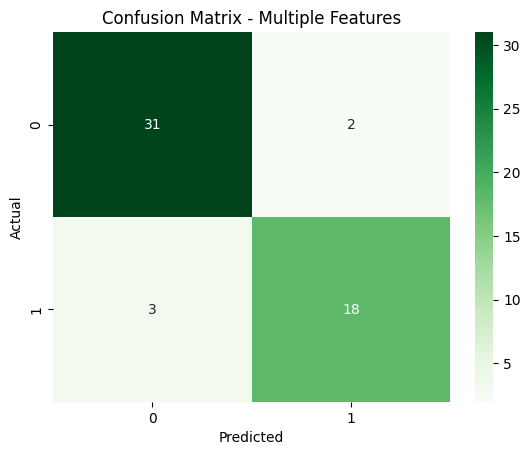

In [11]:
y_pred_m = model_multi.predict(X_test_m_scaled)

print("Task 2 Classification Report:\n", classification_report(y_test, y_pred_m))

# Confusion Matrix
cm_multi = confusion_matrix(y_test, y_pred_m)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Multiple Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Discussion and Model Evaluation

Which Model Performs Better and Why?

The Logistic Regression model trained using multiple features (Task 2) performs significantly better than the model trained using only the Cholesterol feature (Task 1). This improvement is reflected in higher evaluation metrics such as accuracy, precision, recall, and F1-score. Heart disease is a complex medical condition influenced by several factors, including age, blood pressure, chest pain type, heart rate, and cholesterol levels. Relying on a single feature provides limited information, whereas incorporating multiple relevant features allows the model to identify more meaningful patterns and relationships within the data, resulting in more accurate predictions.

Effect of Adding More Features on Accuracy and Recall

Adding relevant features generally improves the predictive performance of a machine learning model. In this case, the inclusion of multiple patient health indicators increases both accuracy and recall. Accuracy improves because the model has access to a broader set of information, enabling it to classify patients more effectively.

Recall, which measures the model's ability to correctly identify patients with heart disease, is particularly important in medical applications. A higher recall reduces the number of false negatives, meaning fewer patients with heart disease are incorrectly classified as healthy. Since missing a diagnosis can have serious consequences, improving recall is often a primary objective in healthcare-related predictive models.

Trade-Off Between Interpretability and Performance

Single-Feature Model

The single-feature Logistic Regression model offers high interpretability but lower predictive performance. Since only cholesterol is used as the input variable, the relationship between the feature and the prediction can be easily visualized and explained. Stakeholders can clearly understand how changes in cholesterol levels affect the probability of heart disease. However, the model's simplicity limits its ability to capture the complexity of real-world medical conditions.

Multi-Feature Model

The multi-feature Logistic Regression model provides substantially better predictive performance but is less interpretable. By considering multiple health indicators simultaneously, the model can capture complex relationships that are not visible when using a single feature. Although feature coefficients can still provide insights into the importance of individual variables, understanding the combined influence of all features becomes more challenging. Despite this reduction in interpretability, the significant improvement in prediction accuracy and recall makes the multi-feature approach more suitable for practical heart disease prediction.
